In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [2]:
mintues=np.array([60, 90, 90, 120, 240])
np.mean(mintues)
np.median(mintues)
np.var(mintues)
np.std(mintues)

np.float64(62.928530890209096)

# Probablity Mass Function

In [3]:
# Rolling one dice
L=[]
for i in range(10000):
    a=random.randint(1,6)
    L.append(a)




In [4]:
series=pd.Series(L)

In [5]:
probablities=(series.value_counts()/series.value_counts().sum()).sort_index()

<Axes: >

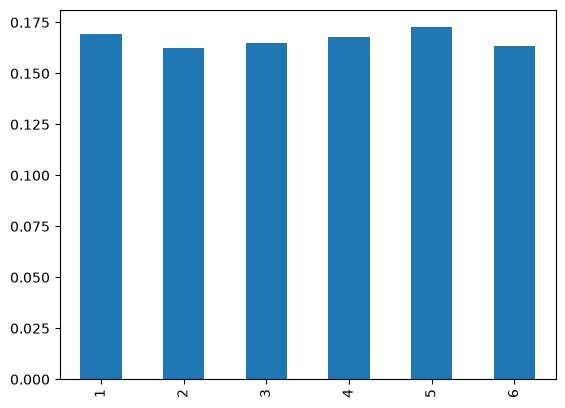

In [6]:
probablities.plot(kind='bar')

In [7]:
# Rolling two dice and probablity of their sum
l=[]
for i in range(10000):
    a=random.randint(1,6)
    b=random.randint(1,6)

    l.append(a+b)

In [8]:
two_dice_series=pd.Series(l)
probablities_two_dice=two_dice_series.value_counts().sort_index()/two_dice_series.value_counts().sum()

<Axes: >

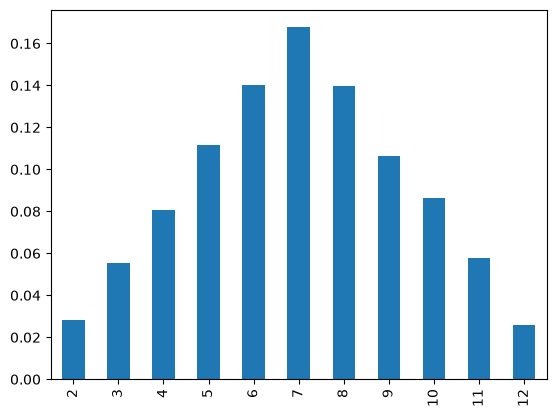

In [9]:
probablities_two_dice.plot(kind='bar')

# Cumulative Distribution Function

<Axes: >

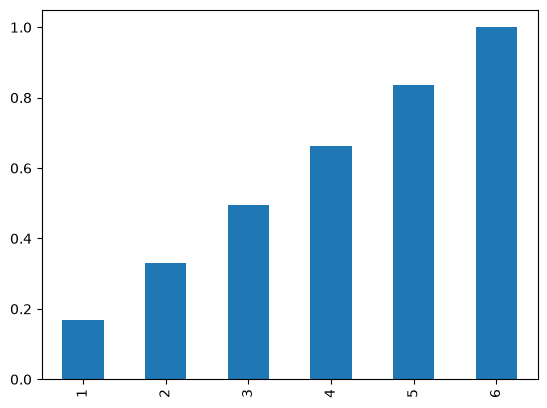

In [10]:
# For one dice
np.cumsum(probablities).plot(kind='bar')

<Axes: >

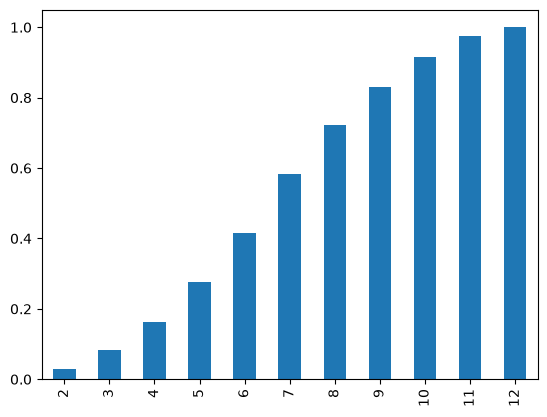

In [11]:
np.cumsum(probablities_two_dice).plot(kind='bar')

# Probability Density Function

Parametric Density Estimation

In [5]:
from numpy.random import normal

sample=normal(loc=50,scale=5,size=1000)

In [6]:
sample_mean=sample.mean()
sample_std=sample.std()

In [7]:
from scipy.stats import norm

dist=norm(sample_mean,sample_std)

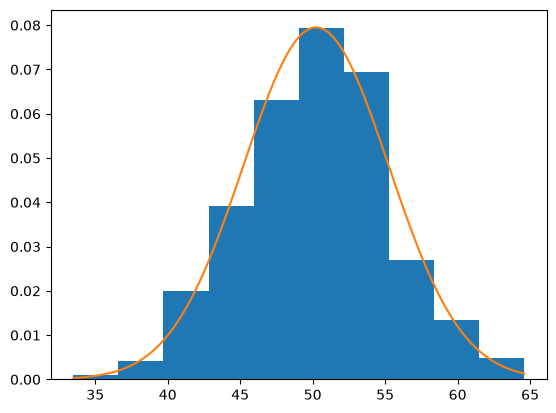

In [32]:
values=np.linspace(sample.min(),sample.max(),100)
probablities=[dist.pdf(value) for value in values]

plt.hist(sample,bins=10,density=True)
plt.plot(values,probablities)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3184\3311749440.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  snc.distplot(sample)


<Axes: ylabel='Density'>

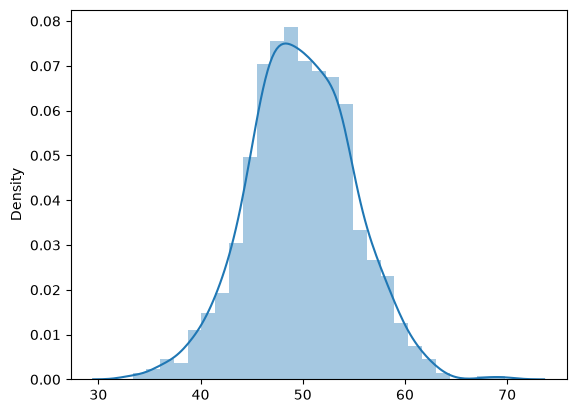

In [8]:
import seaborn as snc

snc.distplot(sample)

# Kernel Density Estimation

In [42]:
sample1=normal(loc=40,scale=5,size=700)
sample2=normal(loc=20,scale=5,size=300)
sample=np.hstack((sample1,sample2))

(array([ 17.,  43., 110.,  86.,  50., 105., 237., 233.,  97.,  22.]),
 array([ 6.67923667, 11.40317038, 16.12710409, 20.85103781, 25.57497152,
        30.29890523, 35.02283894, 39.74677265, 44.47070637, 49.19464008,
        53.91857379]),
 <BarContainer object of 10 artists>)

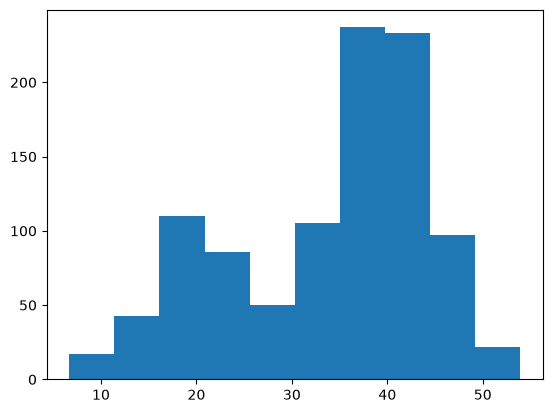

In [43]:
plt.hist(sample)

In [9]:
from sklearn.neighbors import KernelDensity

model=KernelDensity(bandwidth=3,kernel='gaussian')

sample=sample.reshape(-1,1)

model.fit(sample)

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",3
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None
Name,Type,Value
"bandwidth_ bandwidth_: floatValue of the bandwidth, given directly by the bandwidth parameter orestimated using the 'scott' or 'silverman' method... versionadded:: 1.0",int,3


In [53]:
values=np.linspace(sample.min(),sample.max(),100)
values=values.reshape(-1,1)

In [54]:
probablities=model.score_samples(values)
probablities=np.exp(probablities)

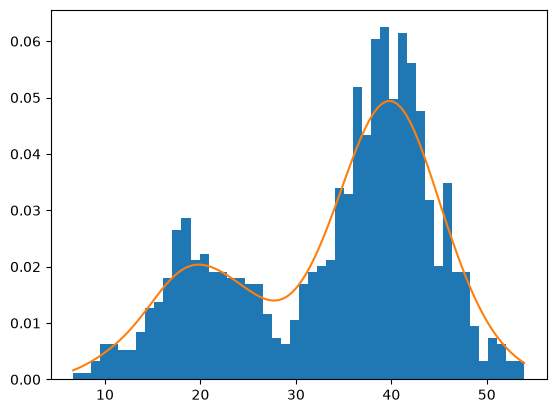

In [58]:
plt.hist(sample,bins=50,density=True)
plt.plot(values[:],probablities)

<Axes: ylabel='Density'>

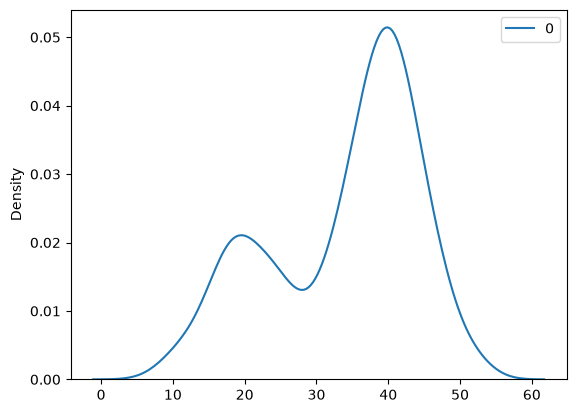

In [65]:
snc.kdeplot(sample)

In [115]:
insurance=pd.read_csv('insurance_data - insurance_data.csv')
insurance['age']=insurance['age'].fillna(insurance['age'].median())

### Q-1: What is the probability distribution of age in the insurance dataset?

-- Find out using the KDE method

<Axes: xlabel='age', ylabel='Density'>

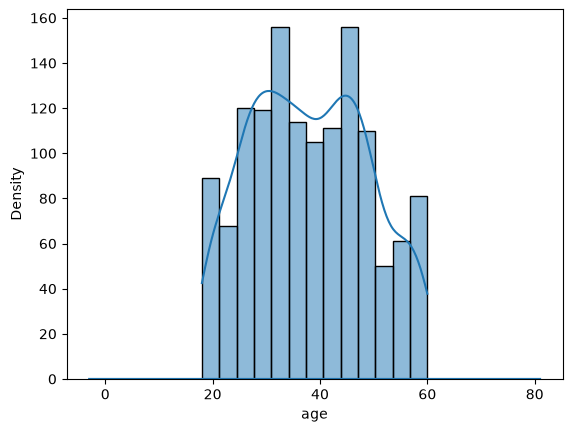

In [130]:
insurance['age'].plot(kind='kde')
snc.histplot(insurance['age'],kde=True)

In [126]:
model=KernelDensity(bandwidth=3,kernel='gaussian')

model.fit(insurance['age'].to_numpy().reshape(-1,1))

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",3
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None
Name,Type,Value
"bandwidth_ bandwidth_: floatValue of the bandwidth, given directly by the bandwidth parameter orestimated using the 'scott' or 'silverman' method... versionadded:: 1.0",int,3


In [127]:
values=np.linspace(insurance['age'].min(),insurance['age'].max(),100)
values=values.reshape(-1,1)

In [128]:
probablities=model.score_samples(values)
probablities=np.exp(probablities)

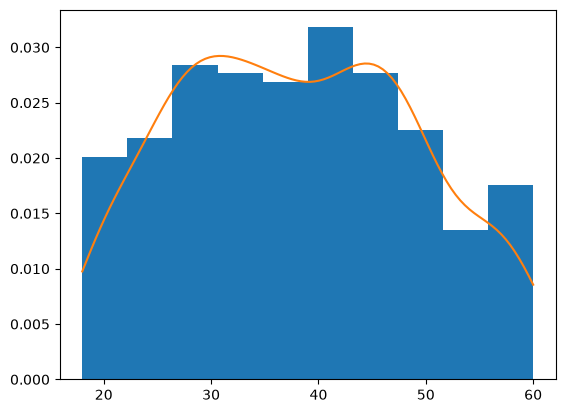

In [129]:
plt.hist(insurance['age'],bins=10,density=True)
plt.plot(values[:],probablities)

<Axes: xlabel='age', ylabel='Density'>

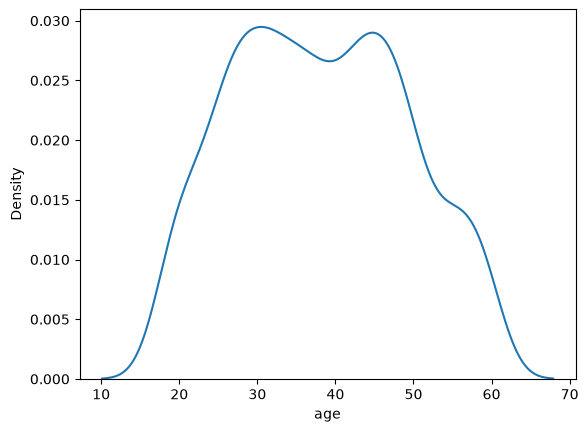

In [131]:
snc.kdeplot(insurance['age'])

# Q-2: What is the probability of a patient having a BMI greater than 30?

In [142]:
total_people=len(insurance)
people_having_30_bmi=len(insurance[insurance['bmi']>30])

probability=people_having_30_bmi/total_people
probability

0.5216417910447761

# Q-3: Plot distribution plot of claim for Smoker and non smoker. What changes you see in the plot?

<Axes: xlabel='claim', ylabel='Count'>

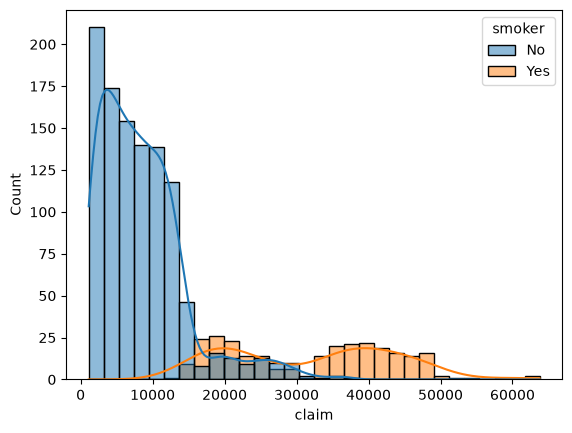

In [159]:
snc.histplot(data=insurance,x='claim',hue='smoker',kde=True)

# Q-4: Plot the 2D probability density plot of claim and age in the insurance dataset?

<Axes: xlabel='age', ylabel='claim'>

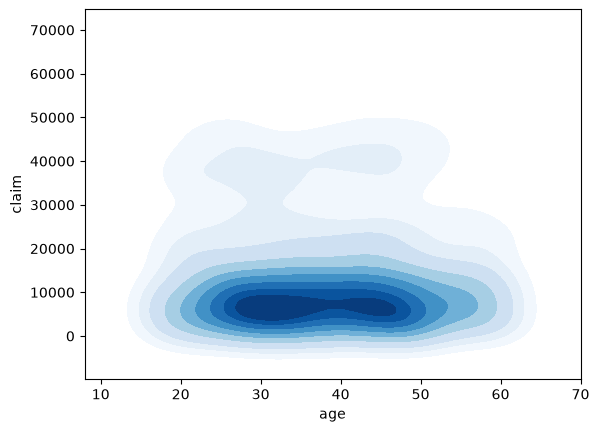

In [166]:
snc.kdeplot(data=insurance,y='claim',x='age',cmap='Blues',thresh=0.05,fill=True)

#  Q5. How does the disribution of claim changes for different region? Plot density plot and note down the observations

<Axes: xlabel='claim', ylabel='Density'>

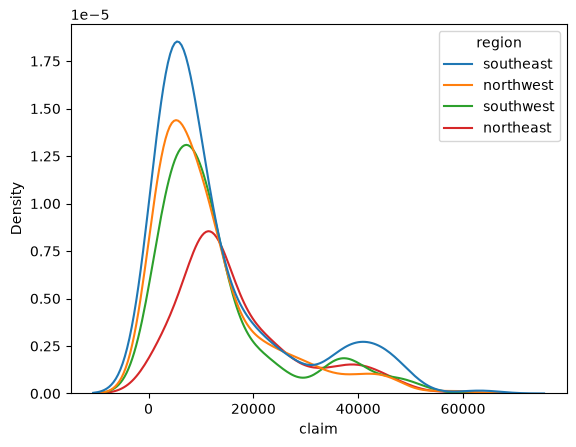

In [162]:
snc.kdeplot(data=insurance,x='claim',hue='region')

# Plot PDF and CDF of claim in insurance data

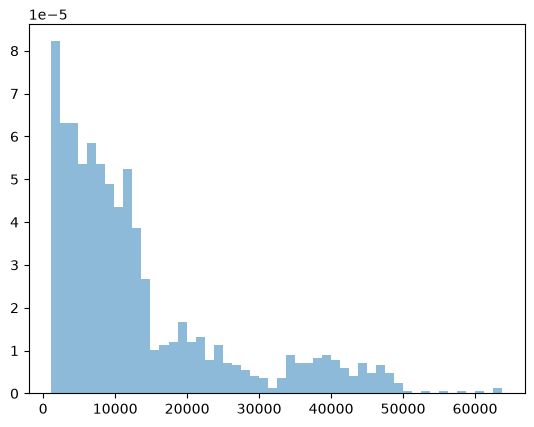

In [171]:
claim_data=insurance.claim
plt.hist(claim_data,density=True, alpha=0.5,bins=50)
plt.show()

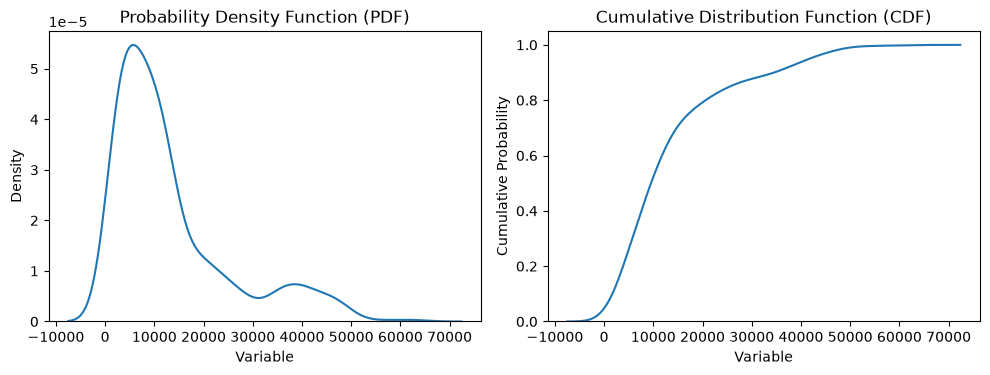

In [182]:
data=claim_data

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
snc.kdeplot(data)
plt.xlabel('Variable')
plt.ylabel('Density')
plt.title('Probability Density Function (PDF)')

plt.subplot(1,2,2)
snc.kdeplot(data,cumulative=True)
plt.xlabel('Variable')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function (CDF)')

plt.tight_layout()
plt.show()

# Q-7: Given a probability density function f(x) = 2x for 0 <= x <= 1 and f(x) = 0 otherwise, compute the cumulative distribution function F(x) and plot it. Use this to find the probability that X is greater than 0.5.


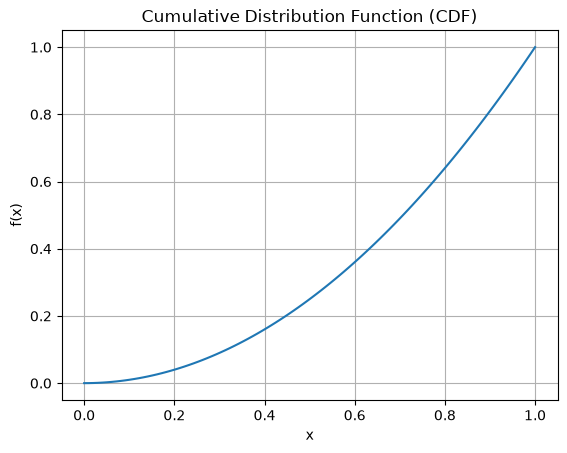

Probability X > 0.5: 0.75


In [200]:
def pdf(x):
    if 0<=x<=1:
        return 2*x
    else:
        return 0
    
def cdf(x):
    if x<0:
        return 0
    
    elif 0<=x<=1:
        return x**2
    
    else:
        return 1
    
values=np.linspace(0,1,100)
# CDF 
y_cdf=np.array([cdf(val)  for val in values])

plt.plot(values,y_cdf)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Cumulative Distribution Function (CDF)')
plt.grid(True)
plt.show()

prob_greater_than_05 = 1 - cdf(0.5)
print(f"Probability X > 0.5: {prob_greater_than_05}")

# Q-8: In a manufacturing process, the thickness of a certain material is known to be normally distributed with a mean of 1.2 mm and a standard deviation of 0.05 mm. What is the probability density function of the thickness? Plot the PDF and use it to compute the probability that the thickness is between 1.1 mm and 1.3 mm.

The probability density function (PDF) of a normal distribution with mean μ and standard deviation σ is given by:

f(x) = (1 / (σ * sqrt(2 * π))) * exp(-(x - μ)^2 / (2 * σ^2))

np.float64(0.9544997361036416)

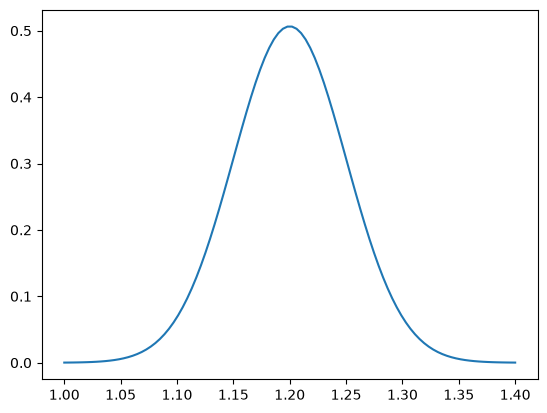

In [34]:
def pdf(x,mean,std):
    return (1/(std*np.square(2*np.pi)))*np.exp(-(x-mean)**2/(2*std**2))

dist=norm(1.2,0.05)
values=np.linspace(1.0,1.4,100)
y_pdf=pdf(values,1.2,0.05)

# probablities=dist.pdf(values)

cdf=dist.cdf(1.3)-dist.cdf(1.1)
plt.plot(values,y_pdf)

cdf


# Q-8 : A data scientist is investigating the distribution of customer ages in a retail store. She collects a sample of 100 ages and estimates the probability density function using kernel density estimation. What bandwidth should she choose to obtain the best estimate?

#### Solution:

Choosing the best bandwidth for KDE involves finding a balance between overfitting and underfitting. If the bandwidth is too small, the estimated PDF may have a lot of small, spurious oscillations or noise, which may not accurately represent the underlying distribution of the data. On the other hand, if the bandwidth is too large, the estimated PDF may be overly smooth and may not capture the finer details or variations in the data.

There are several methods that can be used to select the optimal bandwidth for KDE, including cross-validation, rule-of-thumb methods (e.g., Scott's rule, Silverman's rule), and optimization techniques (e.g., maximum likelihood estimation).

One common rule-of-thumb method for choosing the bandwidth in KDE is Scott's rule, which is given by:

`h = 1.06 * sigma * n^(-1/5)`

where `h` is the bandwidth, sigma is the standard deviation of the data, and `n` is the number of data points in the sample. Scott's rule is often used as a default bandwidth choice in many KDE implementations.

In [35]:
# Scott's Approach
best_bandwith=1.06*10*(100**(-1/5))
best_bandwith

4.219936007867071

In [40]:
# Cross validation approach
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

# Generate a sample of 100 ages
ages = np.random.normal(loc=40, scale=10, size=100)

# Define the range of bandwidths to test
bandwidths = 10 ** np.linspace(-1, 1, 100)

# Define the parameters for the kernel density estimator
params = {'bandwidth': bandwidths, 'kernel': ['gaussian']}

# Create a GridSearchCV object to find the best bandwidth
grid = GridSearchCV(KernelDensity(), params, cv=5)
grid.fit(ages.reshape(-1, 1))

# Extract the best bandwidth from the GridSearchCV object
best_bandwidth = grid.best_estimator_.bandwidth
print('Best bandwidth:', best_bandwidth)


Best bandwidth: 5.214008287999687
